In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'sudoku.png'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(563, 558, 3)

In [3]:
def translation(tx, ty):
    return np.array([[1, 0, tx], [0, 1, ty], [0, 0, 1]], dtype=np.float64)


def rotation(angle, c):
    a = np.deg2rad(angle)
    R = np.array([[np.cos(a), np.sin(a), 0], [-np.sin(a), np.cos(a), 0], [0, 0, 1]])
    return translation(*c) @ R @ translation(-c[0], -c[1])


def scaling(s, c):
    S = np.array([[s, 0, 0], [0, s, 0], [0, 0, 1]], dtype=np.float64)
    return translation(*c) @ S @ translation(-c[0], -c[1])

In [4]:
h, w = img.shape[:2]
c = np.array([w / 2, h / 2])
canvas = (700, 700)
corner = np.array([520, 520])
s, angle = 0.4, 25

D = rotation(angle, corner) @ translation(*(corner - c)) @ scaling(s, c)
blueprint = cv2.warpAffine(img, D[:2], canvas)

In [5]:
center = np.array([350, 350])

R = rotation(-angle, corner)
S = scaling(1 / s, corner)
T = translation(*(center - corner))
M = T @ S @ R

fixed = cv2.warpAffine(blueprint, M[:2], canvas)

print(np.round(M, 3))
print('scale factor:', round(np.sqrt(np.linalg.det(M[:2, :2])), 3))

[[ 2.266000e+00 -1.057000e+00 -2.787960e+02]
 [ 1.057000e+00  2.266000e+00 -1.377604e+03]
 [ 0.000000e+00  0.000000e+00  1.000000e+00]]
scale factor: 2.5


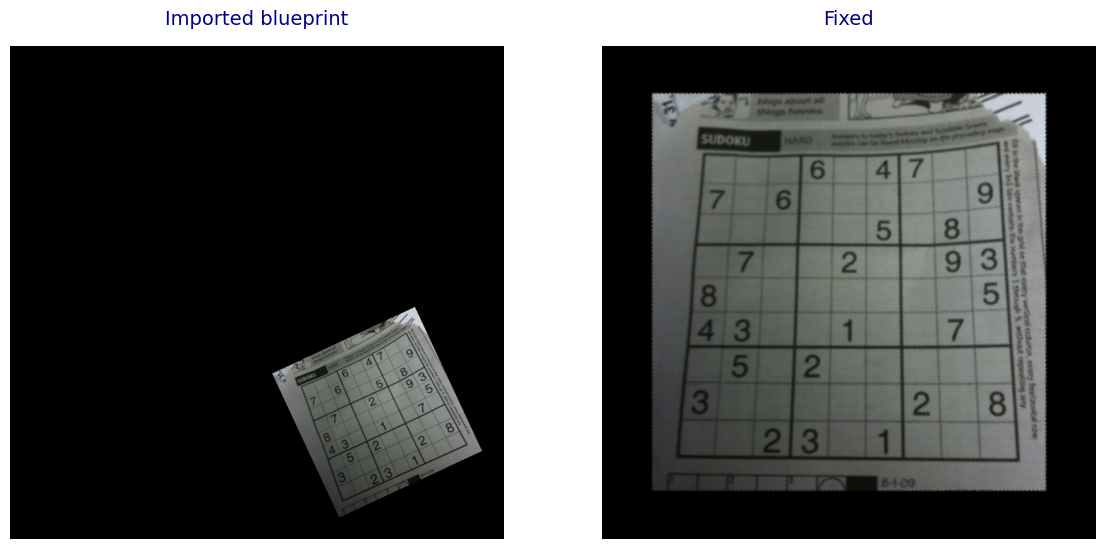

In [6]:
panels = [('Imported blueprint', blueprint), ('Fixed', fixed)]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [7]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task6_blueprint.png', cv2.cvtColor(fixed, cv2.COLOR_RGB2BGR))

True

Fixing is three steps in one matrix, M = T @ S @ R. Rotate back by -25 about the blueprint center, scale by 1/0.4 = 2.5 about the same point and then move that point to the middle of the window.

Scale factor from the determinant is 2.5 so that checks out. Angles are preserved, the squares of the grid are still squares, only the size changed. Unlike the rigid one this has a scale in it so lengths change but shape doesn't.